### Plots for Word Frequency

In [2]:
import pandas as pd

# Replace 'data_cleaned.csv' with your actual file path if needed
data_cleaned = pd.read_csv('Data/data_cleaned.csv')

from collections import Counter

#Create a word frequency count
# Create an empty dictionary to store counters for each target
word_freq_by_target = {}

# Loop through each unique target
for target in data_cleaned['target'].unique():
    # Filter rows for the current target
    target_df = data_cleaned[data_cleaned['target'] == target]
    
    # Combine all clean_text into one big string
    all_text = " ".join(target_df['clean_text'].dropna().astype(str))
    
    # Tokenize by splitting on whitespace (assuming clean_text is already cleaned)
    words = all_text.split()
    
    # Count word frequencies
    word_counter = Counter(words)
    
    # Store the 10 most common words for this target
    word_freq_by_target[target] = word_counter.most_common(10)

# Display the results
for target, word_list in word_freq_by_target.items():
    print(f"\nTarget: {target}")
    for word, freq in word_list:
        print(f"  {word}: {freq}")


Target: gender
  women: 62559
  protest: 28796
  violence: 18964
  woman: 18124
  members: 17228
  city: 16816
  people: 16575
  held: 13998
  police: 13838
  staged: 12864

Target: health
  health: 33538
  workers: 30387
  protest: 19182
  hospital: 18048
  medical: 10567
  city: 9797
  demand: 9529
  staged: 9225
  protested: 8512
  doctors: 8337

Target: journalists
  journalists: 15331
  journalist: 8700
  city: 7382
  media: 7164
  police: 6656
  protest: 6434
  arrest: 6109
  arrested: 4861
  group: 4603
  protested: 3859

Target: peacekepers
  forces: 871
  monusco: 780
  group: 692
  fatalities: 649
  killed: 577
  peacekeepers: 558
  minusma: 538
  around: 481
  minusca: 458
  fardc: 455


In [3]:
#Turn into a frequency table
# Flatten the dictionary into rows
rows = []
for target, word_list in word_freq_by_target.items():
    for word, freq in word_list:
        rows.append({'target': target, 'word': word, 'frequency': freq})

# Create DataFrame
freq_df = pd.DataFrame(rows)

#Preview
print(freq_df.head(15))

    target      word  frequency
0   gender     women      62559
1   gender   protest      28796
2   gender  violence      18964
3   gender     woman      18124
4   gender   members      17228
5   gender      city      16816
6   gender    people      16575
7   gender      held      13998
8   gender    police      13838
9   gender    staged      12864
10  health    health      33538
11  health   workers      30387
12  health   protest      19182
13  health  hospital      18048
14  health   medical      10567


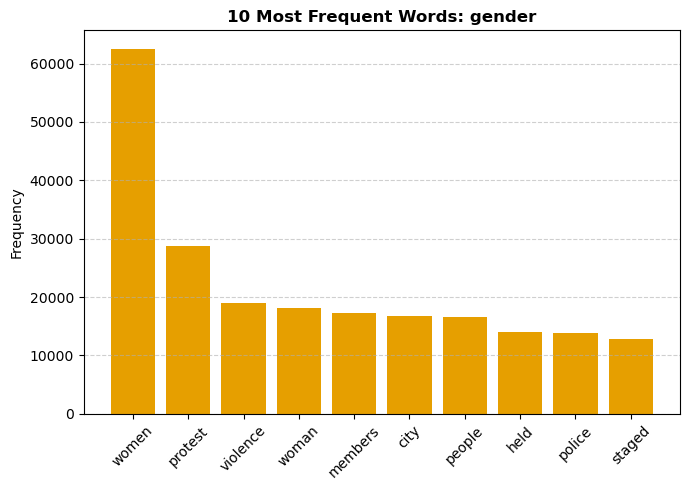

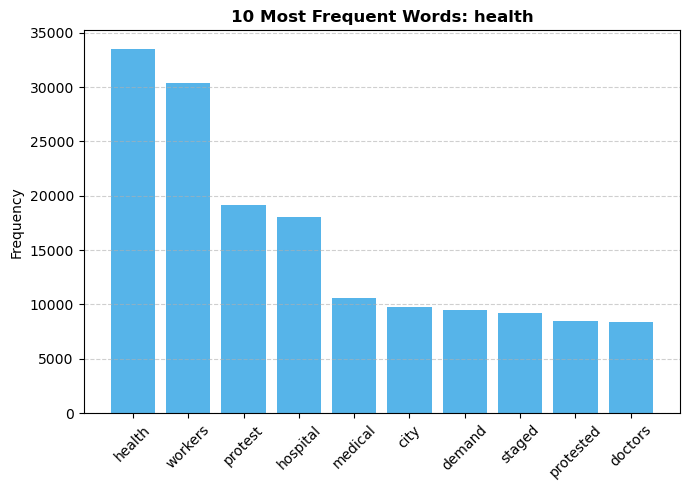

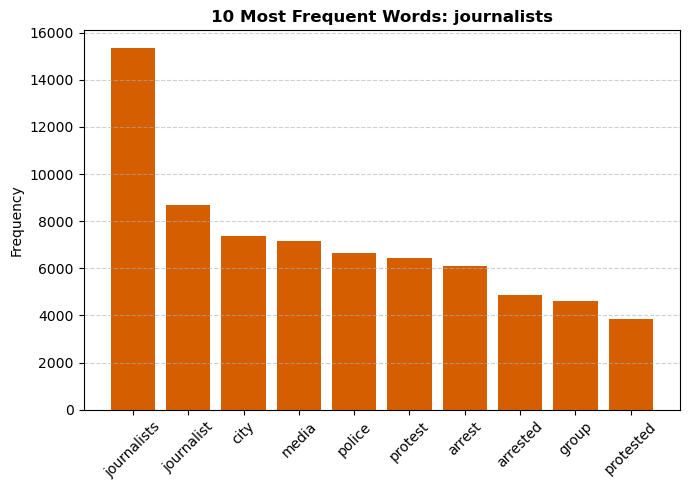

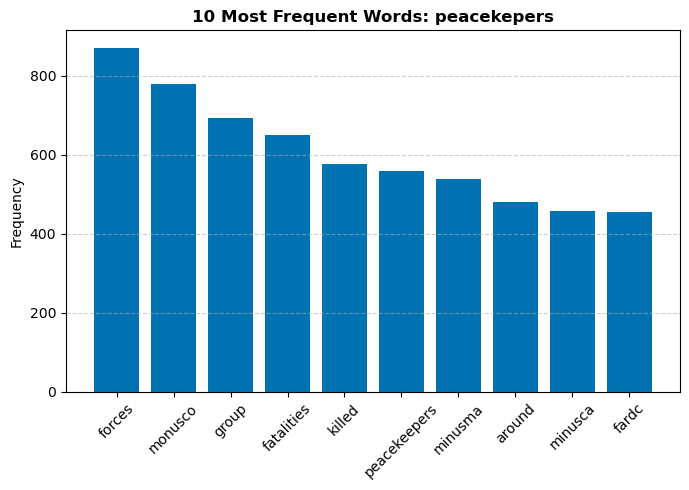

In [4]:
import matplotlib.pyplot as plt

# Professional color palette
colors = ['#E69F00', '#56B4E9', '#D55E00', '#0072B2']

# One plot per target
for i, (target, word_list) in enumerate(word_freq_by_target.items()):
    words, freqs = zip(*word_list)
    
    plt.figure(figsize=(7, 5))
    plt.bar(words, freqs, color=colors[i % len(colors)])
    plt.title(f"10 Most Frequent Words: {target}", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot
    filename = f"word_frequency_{str(target).lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    
    # Show the plot
    plt.show()

    # Close to avoid overlap in next figure
    plt.close()


In [5]:
#Combine into one image
from PIL import Image

# Open each plot image
img1 = Image.open("word_frequency_gender.png")
img2 = Image.open("word_frequency_peacekepers.png")
img3 = Image.open("word_frequency_journalists.png")
img4 = Image.open("word_frequency_health.png")

# Assuming all images are the same size
width, height = img1.size
combined = Image.new('RGB', (width * 2, height * 2))

# Paste them in a 2x2 grid
combined.paste(img1, (0, 0))
combined.paste(img2, (width, 0))
combined.paste(img3, (0, height))
combined.paste(img4, (width, height))

combined.save("combined_word_frequencies.png")
combined.show()

Do the same but after having removed keywords: 

In [10]:
df = pd.read_csv('data_cleaned.csv')

#filter key word
import re

# List of words to remove (case-insensitive)
frequent_words = ['women', 'woman', 'peacekeepers', 'journalists', 'journalist', 'health']

# Combine into regex pattern for whole words only
pattern = r'\b(?:' + '|'.join(re.escape(word) for word in frequent_words) + r')\b'

# Remove words from clean_text
df['clean_text'] = df['clean_text'].str.replace(pattern, '', case=False, regex=True)

# Remove extra whitespace
df['clean_text'] = df['clean_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [12]:
df.head()

,notes,event_id_cnty,target,clean_text
0,"On 25 April 2025, in Capilla del Monte (Cordob...",ARG16601,gender,capilla del monte cordoba large group people i...
1,"Around 25 April 2025 (as reported), in Salvado...",BRA96908,gender,around reported salvador bahia cv members shot...
2,"On 25 April 2025, about 200 Israelis from the ...",ISR45719,gender,israelis shift movement protested jerusalem ju...
3,"On 25 April 2025, in Leon de los Aldama, Guana...",MEX103000,gender,leon de los aldama guanajuato shot dead armed ...
4,"On 25 April 2025, in Sabanas de Xalostoc, Vera...",MEX103223,gender,sabanas de xalostoc veracruz armed individuals...


In [20]:
#Create a word frequency count
# Create an empty dictionary to store counters for each target
word_freq_by_target_clean = {}

# Loop through each unique target
for target in df['target'].unique():
    # Filter rows for the current target
    target_df = df[df['target'] == target]
    
    # Combine all clean_text into one big string
    all_text = " ".join(target_df['clean_text'].dropna().astype(str))
    
    # Tokenize by splitting on whitespace (assuming clean_text is already cleaned)
    words = all_text.split()
    
    # Count word frequencies
    word_counter = Counter(words)
    
    # Store the 10 most common words for this target
    word_freq_by_target_clean[target] = word_counter.most_common(10)

# Display the results
for target, word_list in word_freq_by_target_clean.items():
    print(f"\nTarget: {target}")
    for word, freq in word_list:
        print(f"  {word}: {freq}")


Target: gender
  protest: 28796
  violence: 18964
  members: 17228
  city: 16816
  people: 16575
  held: 13998
  police: 13838
  staged: 12864
  group: 12229
  gathered: 11886

Target: health
  workers: 30387
  protest: 19182
  hospital: 18048
  medical: 10567
  city: 9797
  demand: 9529
  staged: 9225
  protested: 8512
  doctors: 8337
  nurses: 8217

Target: journalists
  city: 7382
  media: 7164
  police: 6656
  protest: 6434
  arrest: 6109
  arrested: 4861
  group: 4603
  protested: 3859
  attack: 3748
  demanded: 3607

Target: peacekepers
  forces: 871
  monusco: 780
  group: 692
  fatalities: 649
  killed: 577
  minusma: 538
  around: 481
  minusca: 458
  fardc: 455
  engaged: 427


In [21]:
#Turn into a frequency table
# Flatten the dictionary into rows
rows = []
for target, word_list in word_freq_by_target_clean.items():
    for word, freq in word_list:
        rows.append({'target': target, 'word': word, 'frequency': freq})

# Create DataFrame
freq_df_clean = pd.DataFrame(rows)

#Preview
print(freq_df_clean.head(15))

    target      word  frequency
0   gender   protest      28796
1   gender  violence      18964
2   gender   members      17228
3   gender      city      16816
4   gender    people      16575
5   gender      held      13998
6   gender    police      13838
7   gender    staged      12864
8   gender     group      12229
9   gender  gathered      11886
10  health   workers      30387
11  health   protest      19182
12  health  hospital      18048
13  health   medical      10567
14  health      city       9797


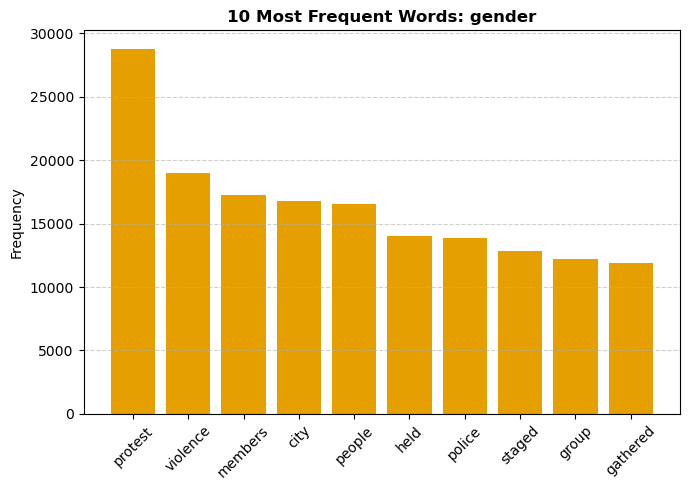

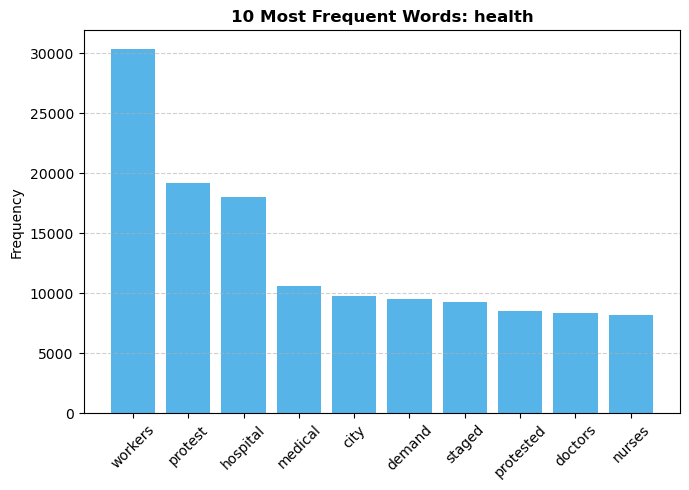

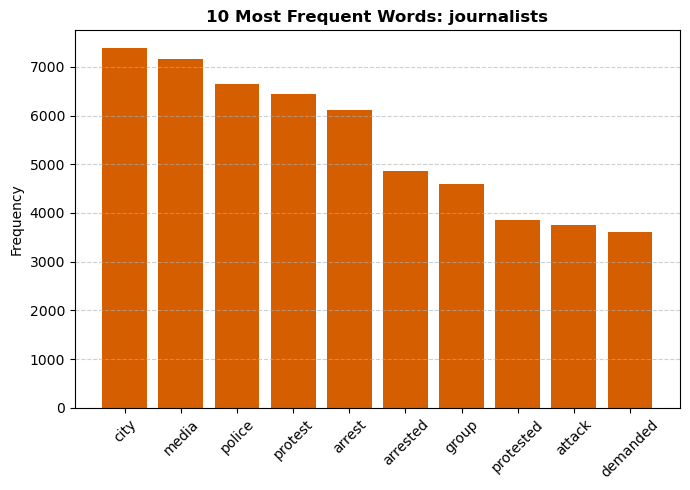

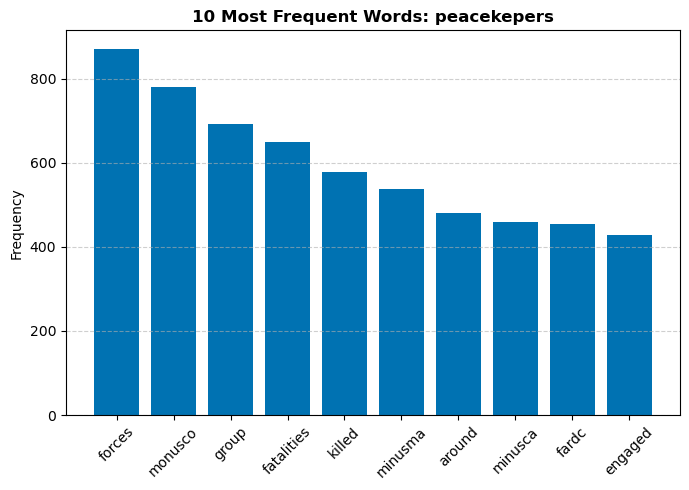

In [22]:
# One plot per target
for i, (target, word_list) in enumerate(word_freq_by_target_clean.items()):
    words, freqs = zip(*word_list)
    
    plt.figure(figsize=(7, 5))
    plt.bar(words, freqs, color=colors[i % len(colors)])
    plt.title(f"10 Most Frequent Words: {target}", fontsize=12, fontweight='bold')
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot
    filename = f"word_frequency_{str(target).lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    
    # Show the plot
    plt.show()

    # Close to avoid overlap in next figure
    plt.close()


In [23]:
# Open each plot image
img1 = Image.open("word_frequency_gender.png")
img2 = Image.open("word_frequency_peacekepers.png")
img3 = Image.open("word_frequency_journalists.png")
img4 = Image.open("word_frequency_health.png")

# Assuming all images are the same size
width, height = img1.size
combined = Image.new('RGB', (width * 2, height * 2))

# Paste them in a 2x2 grid
combined.paste(img1, (0, 0))
combined.paste(img2, (width, 0))
combined.paste(img3, (0, height))
combined.paste(img4, (width, height))

combined.save("combined_word_frequencies_clean.png")
combined.show()